# 第 1 章 · 机器学习概览

本章用鸢尾花数据集走完一个完整的 ML 流程：数据加载 → EDA → 划分 → 训练 → 评估 → 混淆矩阵，作为后续章节的“骨架”。本章不手写算法，重点在流程。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 中文字体配置（仅在此cell设置一次，后续cell直接使用plt即可）
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'primary': '#6b6144', 'accent': '#96781b', 'accent2': '#459ebb',
    'pos': '#c0392b', 'neg': '#2980b9', 'green': '#3d8e58', 'muted': '#88867f'
}

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 1.1 数据加载与 EDA

鸢尾花 (Iris) 150 条样本，4 个特征 (花萼/花瓣 长宽)，3 类目标。

   sepal_length  sepal_width  petal_length  petal_width  target
0           5.1          3.5           1.4          0.2       0
1           4.9          3.0           1.4          0.2       0
2           4.7          3.2           1.3          0.2       0
3           4.6          3.1           1.5          0.2       0
4           5.0          3.6           1.4          0.2       0
\n类别: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
形状: (150, 5)


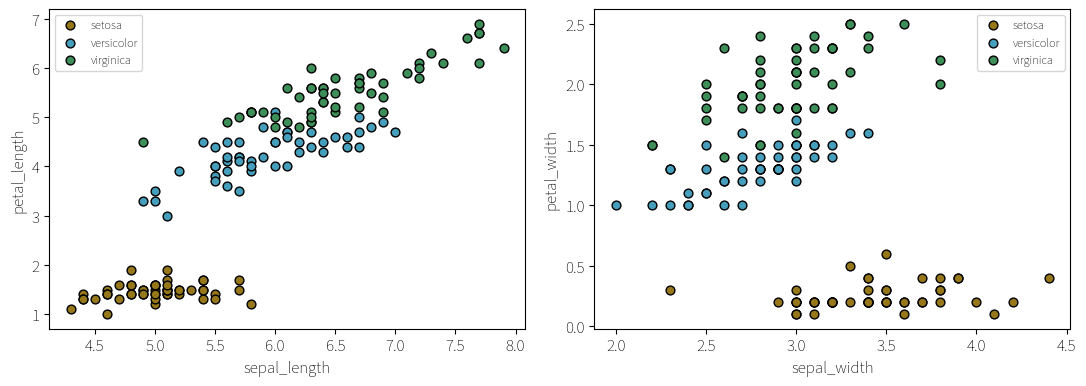

In [2]:
data = load_iris(as_frame=True)
df = data.frame.copy()
df.columns = [c.replace(' (cm)','').replace(' ','_') for c in df.columns]
print(df.head())
print('\\n类别:', list(data.target_names))
print('形状:', df.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, (a, b) in enumerate([('sepal_length','petal_length'),
                            ('sepal_width','petal_width')]):
    for j, name in enumerate(data.target_names):
        sub = df[df['target']==j]
        axes[i].scatter(sub[a], sub[b], label=name,
                        c=[COLORS['accent'],COLORS['accent2'],COLORS['green']][j],
                        edgecolor='k', s=40)
    axes[i].set_xlabel(a); axes[i].set_ylabel(b); axes[i].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 1.2 划分 + 标准化

训练/测试 7:3，并对特征做标准化 (均值0方差1)，让基于距离/梯度的模型稳定。

In [3]:
X = df.drop(columns='target').values
y = df['target'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print('训练集:', X_train.shape, '测试集:', X_test.shape)


训练集: (105, 4) 测试集: (45, 4)


## 1.3 训练与评估

用一个 LogisticRegression 作基线，后续章节会换成更复杂的模型并手写实现。

准确率: 0.9111111111111111
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



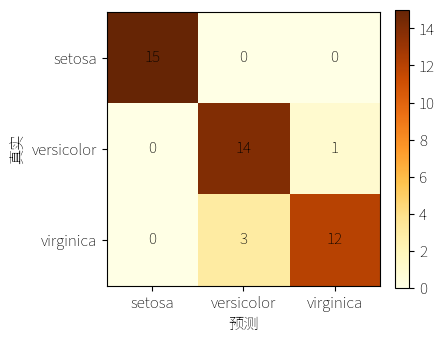

In [4]:
clf = LogisticRegression(max_iter=500, random_state=42)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)
print('准确率:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5,4))
im = ax.imshow(cm, cmap='YlOrBr')
ax.set_xticks(range(3)); ax.set_xticklabels(data.target_names)
ax.set_yticks(range(3)); ax.set_yticklabels(data.target_names)
for i in range(3):
    for j in range(3):
        ax.text(j,i,cm[i,j],ha='center',va='center')
ax.set_xlabel('预测'); ax.set_ylabel('真实')
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()


## 1.4 小结

完整 ML 流程 = 数据 → EDA → 划分 → 预处理 → 训练 → 评估 → 可视化。
从下一章起，我们会把“训练”这一步从【调 sklearn】升级为【自己用 NumPy 写一遍 + 再对比 sklearn】，且代码步骤与 PDF 伪代码一一对应。